In [1]:
import numpy as np
import heapq
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from enum import Enum
import random
from typing import List, Tuple, Dict, Optional
import math

In [2]:
class TerrainType(Enum):
    FLAT = 0
    SANDY = 1
    ROCKY = 2
    RADIATION = 3
    RECHARGE_STATION = 4
    SAMPLE_ZONE = 5

In [3]:
class RoverState:
    def __init__(self, position: Tuple[int, int], battery: float = 100.0):
        self.position = position
        self.battery = battery
        self.path_history = [position]
        self.safe_positions = [position]  # Track safe positions for backtracking

In [4]:
class Grid:
    def __init__(self, width: int, height: int):
        self.width = width
        self.height = height
        self.terrain = np.zeros((height, width), dtype=int)
        self.recharge_stations = []
        self.sample_zones = []

        # Movement costs for different terrains
        self.movement_costs = {
            TerrainType.FLAT: 5,
            TerrainType.SANDY: 10,
            TerrainType.RADIATION: 15,
            TerrainType.ROCKY: 1000,  # Impassable
            TerrainType.RECHARGE_STATION: 5,
            TerrainType.SAMPLE_ZONE: 5
        }

    def set_terrain(self, x: int, y: int, terrain_type: TerrainType):
        if 0 <= x < self.width and 0 <= y < self.height:
            self.terrain[y, x] = terrain_type.value
            if terrain_type == TerrainType.RECHARGE_STATION:
                self.recharge_stations.append((x, y))
            elif terrain_type == TerrainType.SAMPLE_ZONE:
                self.sample_zones.append((x, y))

    def get_terrain(self, x: int, y: int) -> TerrainType:
        if 0 <= x < self.width and 0 <= y < self.height:
            return TerrainType(self.terrain[y, x])
        return TerrainType.ROCKY  # Out of bounds treated as rocky

    ## All positions other than ROCKY are valid:
    def is_valid_position(self, x: int, y: int) -> bool:
        if not (0 <= x < self.width and 0 <= y < self.height):
            return False
        terrain = self.get_terrain(x, y)
        return terrain != TerrainType.ROCKY

    def get_movement_cost(self, x: int, y: int) -> float:
        terrain = self.get_terrain(x, y)
        return self.movement_costs[terrain]

    def generate_random_terrain(self):
        """Generate a random terrain with obstacles, stations, and zones"""
        for y in range(self.height):
            for x in range(self.width):
                rand = random.random()
                if rand < 0.1:  # 10% rocky
                    self.set_terrain(x, y, TerrainType.ROCKY)
                elif rand < 0.3:  # 20% sandy
                    self.set_terrain(x, y, TerrainType.SANDY)
                # elif rand < 0.35:  # 5% radiation
                #     self.set_terrain(x, y, TerrainType.RADIATION)
                else:  # 70% flat
                    self.set_terrain(x, y, TerrainType.FLAT)

        # Add some recharge stations
        num_stations = max(2, (self.width * self.height) // 100)
        for _ in range(num_stations):
            while True:
                x, y = random.randint(0, self.width-1), random.randint(0, self.height-1)
                if self.get_terrain(x, y) != TerrainType.ROCKY:
                    self.set_terrain(x, y, TerrainType.RECHARGE_STATION)
                    break

        # Add sample zones
        num_samples = max(1, (self.width * self.height) // 150)
        for _ in range(num_samples):
            while True:
                x, y = random.randint(0, self.width-1), random.randint(0, self.height-1)
                if self.get_terrain(x, y) == TerrainType.FLAT:
                    self.set_terrain(x, y, TerrainType.SAMPLE_ZONE)
                    break

In [5]:
class AStarHeuristics:
    @staticmethod
    def manhattan_distance(pos1: Tuple[int, int], pos2: Tuple[int, int]) -> float:
        """Manhattan distance heuristic - admissible"""
        return abs(pos1[0] - pos2[0]) + abs(pos1[1] - pos2[1])

    @staticmethod
    def euclidean_distance(pos1: Tuple[int, int], pos2: Tuple[int, int]) -> float:
        """Euclidean distance heuristic - admissible"""
        return math.sqrt((pos1[0] - pos2[0])**2 + (pos1[1] - pos2[1])**2)

    @staticmethod
    def chebyshev_distance(pos1: Tuple[int, int], pos2: Tuple[int, int]) -> float:
        """Chebyshev distance heuristic - admissible for 8-directional movement"""
        return max(abs(pos1[0] - pos2[0]), abs(pos1[1] - pos2[1]))

    @staticmethod
    def weighted_euclidean(pos1: Tuple[int, int], pos2: Tuple[int, int], weight: float = 1.1) -> float:
        """Weighted Euclidean distance - inadmissible but faster"""
        return weight * math.sqrt((pos1[0] - pos2[0])**2 + (pos1[1] - pos2[1])**2)

In [6]:
class AStar:
    def __init__(self, grid: Grid, heuristic_func):
        self.grid = grid
        self.heuristic = heuristic_func

    def get_neighbors(self, pos: Tuple[int, int]) -> List[Tuple[int, int]]:
        """Get valid neighboring positions (4-directional movement)"""
        x, y = pos
        neighbors = []
        for dx, dy in [(0, 1), (1, 0), (0, -1), (-1, 0)]:  # 4-directional
            new_x, new_y = x + dx, y + dy
            if self.grid.is_valid_position(new_x, new_y):
                neighbors.append((new_x, new_y))
        return neighbors

    def search(self, start: Tuple[int, int], goal: Tuple[int, int]) -> Optional[List[Tuple[int, int]]]:
        """A* search algorithm"""
        if start == goal:
            return [start]

        open_set = [(0, start)]
        came_from = {}
        g_score = {start: 0}
        f_score = {start: self.heuristic(start, goal)}
        closed_set = set()

        while open_set:
            current_f, current = heapq.heappop(open_set)

            if current in closed_set:
                continue

            closed_set.add(current)

            if current == goal:
                # Reconstruct path
                path = []
                while current in came_from:
                    path.append(current)
                    current = came_from[current]
                path.append(start)
                return path[::-1]

            for neighbor in self.get_neighbors(current):
                if neighbor in closed_set:
                    continue

                tentative_g = g_score[current] + self.grid.get_movement_cost(*neighbor)

                if neighbor not in g_score or tentative_g < g_score[neighbor]:
                    came_from[neighbor] = current
                    g_score[neighbor] = tentative_g
                    f_score[neighbor] = tentative_g + self.heuristic(neighbor, goal)
                    heapq.heappush(open_set, (f_score[neighbor], neighbor))

        return None  # No path found

In [7]:
class ReflexAgent:
    def __init__(self, grid: Grid):
        self.grid = grid
        self.state = None

    def perceive(self, position: Tuple[int, int], battery: float) -> Dict:
        """Perceive current environment"""
        terrain = self.grid.get_terrain(*position)

        # Find nearest recharge station
        nearest_station = None
        min_distance = float('inf')
        for station in self.grid.recharge_stations:
            dist = math.sqrt((position[0] - station[0])**2 + (position[1] - station[1])**2)
            if dist < min_distance:
                min_distance = dist
                nearest_station = station

        return {
            'position': position,
            'terrain': terrain,
            'battery': battery,
            'nearest_station': nearest_station,
            'station_distance': min_distance
        }

    def decide_action(self, percepts: Dict, goal: Tuple[int, int]) -> str:
        """Reflex-based decision making"""
        terrain = percepts['terrain']
        battery = percepts['battery']
        position = percepts['position']
        station_distance = percepts['station_distance']

        # Rule 1: If terrain is hazardous at current position, stop and backtrack
        if terrain == TerrainType.RADIATION:
            return "backtrack"

        # Rule 2: Initiate recharge when battery < 20%
        if battery < 20:
            return "seek_recharge"

        # Rule 3: If battery 20-25% and station within 2 moves, go to station
        if 20 <= battery <= 25 and station_distance <= 2:
            return "seek_recharge"

        # Rule 4: If at recharge station, recharge
        if terrain == TerrainType.RECHARGE_STATION and battery < 100:
            return "recharge"

        # Default: continue exploration towards goal
        return "explore"

Starting simulation with Manhattan distance heuristic...
Simulation ended after 19 steps. Goal reached: False

Simulation Statistics:
Total moves: 19
Battery used: 100
Recharges: 0
Backtracks: 0
Final battery: 0.00%


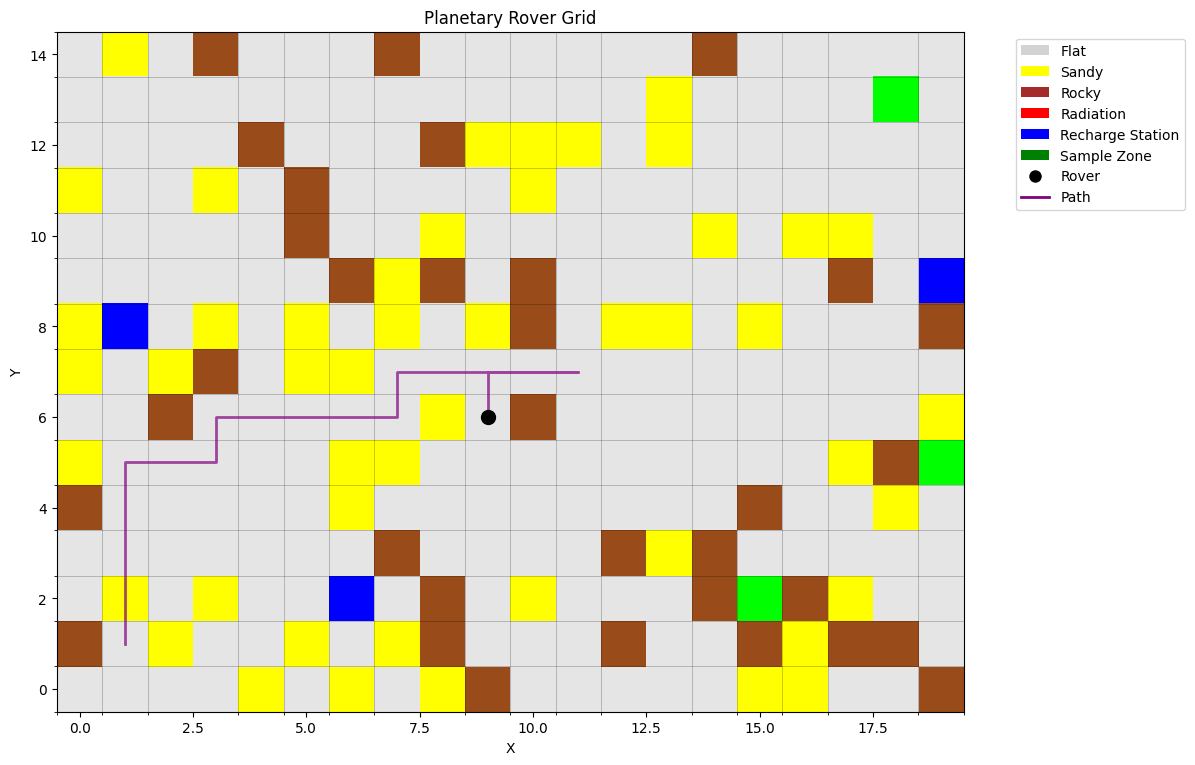

In [8]:
class PlanetaryRover:
    def __init__(self, grid: Grid, start_position: Tuple[int, int]):
        self.grid = grid
        self.state = RoverState(start_position)
        self.reflex_agent = ReflexAgent(grid)
        self.goal = None
        self.current_path = []
        self.path_index = 0

        # Statistics for comparison
        self.stats = {
            'total_moves': 0,
            'battery_used': 0,
            'recharges': 0,
            'backtracks': 0
        }

    def set_goal(self, goal: Tuple[int, int]):
        self.goal = goal

    def plan_path(self, heuristic_func, start: Tuple[int, int], goal: Tuple[int, int]) -> List[Tuple[int, int]]:
        """Plan path using A* with given heuristic"""
        astar = AStar(self.grid, heuristic_func)
        return astar.search(start, goal)

    def move_to_position(self, target: Tuple[int, int]) -> bool:
        """Move rover to target position if possible"""
        if not self.grid.is_valid_position(*target):
            return False

        # Calculate battery cost
        cost = self.grid.get_movement_cost(*target)
        if self.state.battery < cost:
            return False  # Not enough battery

        # Move and update state
        self.state.position = target
        self.state.battery -= cost
        self.state.path_history.append(target)

        # Update safe positions (avoid radiation spots)
        terrain = self.grid.get_terrain(*target)
        if terrain != TerrainType.RADIATION:
            self.state.safe_positions.append(target)

        self.stats['total_moves'] += 1
        self.stats['battery_used'] += cost

        return True

    def backtrack(self):
        """Backtrack to last safe position"""
        if len(self.state.safe_positions) > 1:

            # safe_pos = self.state.safe_positions[-1]  # Go to previous safe position
            safe_pos = self.state.safe_positions[-2]  # Go to previous to previous safe position

            self.state.position = safe_pos
            self.state.path_history.append(safe_pos)
            self.stats['backtracks'] += 1
            print(f"Backtracking to safe position: {safe_pos}")

    def recharge(self):
        """Recharge battery at current position"""
        terrain = self.grid.get_terrain(*self.state.position)
        if terrain == TerrainType.RECHARGE_STATION:
            self.state.battery = 100.0
            self.stats['recharges'] += 1
            print(f"Recharged at {self.state.position}")

    def simulate_step(self, heuristic_func) -> bool:
        """Simulate one step of rover operation"""
        # Perceive environment
        percepts = self.reflex_agent.perceive(self.state.position, self.state.battery)

        # Decide action
        action = self.reflex_agent.decide_action(percepts, self.goal)

        if action == "backtrack":
            self.backtrack()
            return True

        elif action == "recharge":
            self.recharge()
            return True

        elif action == "seek_recharge":
            # Plan path to nearest recharge station
            nearest_station = percepts['nearest_station']
            if nearest_station:
                path = self.plan_path(heuristic_func, self.state.position, nearest_station)
                if path and len(path) > 1:
                    return self.move_to_position(path[1])  # Move one step towards station
            return False

        elif action == "explore":
            # Continue with current path or plan new one
            if not self.current_path or self.path_index >= len(self.current_path) - 1:
                self.current_path = self.plan_path(heuristic_func, self.state.position, self.goal)
                self.path_index = 0

            if self.current_path and self.path_index < len(self.current_path) - 1:
                self.path_index += 1
                return self.move_to_position(self.current_path[self.path_index])

        return False

    def run_simulation(self, heuristic_func, max_steps: int = 1000) -> bool:
        """Run complete simulation until goal reached or max steps"""
        steps = 0
        while steps < max_steps and self.state.position != self.goal:
            if not self.simulate_step(heuristic_func):
                break
            steps += 1

            # Check if goal reached
            if self.state.position == self.goal:
                print(f"Goal reached in {steps} steps!")
                return True

        print(f"Simulation ended after {steps} steps. Goal reached: {self.state.position == self.goal}")
        return self.state.position == self.goal

def create_sample_grid():
    """Create a sample grid for testing"""
    grid = Grid(20, 15)
    grid.generate_random_terrain()

    # Ensure start and goal are accessible
    grid.set_terrain(1, 1, TerrainType.FLAT)  # Start position
    grid.set_terrain(18, 13, TerrainType.SAMPLE_ZONE)  # Goal position

    return grid

def visualize_grid(grid: Grid, rover_pos: Tuple[int, int] = None, path: List[Tuple[int, int]] = None):
    """Visualize the grid with rover position and path"""
    fig, ax = plt.subplots(1, 1, figsize=(12, 9))

    # Color mapping for terrains
    colors = {
        TerrainType.FLAT.value: 'lightgray',
        TerrainType.SANDY.value: 'yellow',
        TerrainType.ROCKY.value: 'brown',
        TerrainType.RADIATION.value: 'red',
        TerrainType.RECHARGE_STATION.value: 'blue',
        TerrainType.SAMPLE_ZONE.value: 'green'
    }

    # Create color array
    color_array = np.zeros((grid.height, grid.width, 3))
    for y in range(grid.height):
        for x in range(grid.width):
            terrain_type = grid.terrain[y, x]
            if terrain_type == TerrainType.FLAT.value:
                color_array[y, x] = [0.9, 0.9, 0.9]  # Light gray
            elif terrain_type == TerrainType.SANDY.value:
                color_array[y, x] = [1.0, 1.0, 0.0]  # Yellow
            elif terrain_type == TerrainType.ROCKY.value:
                color_array[y, x] = [0.6, 0.3, 0.1]  # Brown
            elif terrain_type == TerrainType.RADIATION.value:
                color_array[y, x] = [1.0, 0.0, 0.0]  # Red
            elif terrain_type == TerrainType.RECHARGE_STATION.value:
                color_array[y, x] = [0.0, 0.0, 1.0]  # Blue
            elif terrain_type == TerrainType.SAMPLE_ZONE.value:
                color_array[y, x] = [0.0, 1.0, 0.0]  # Green

    ax.imshow(color_array, origin='lower')

    # Draw path if provided
    if path:
        path_x = [p[0] for p in path]
        path_y = [p[1] for p in path]
        ax.plot(path_x, path_y, 'purple', linewidth=2, alpha=0.7, label='Path')

    # Draw rover position
    if rover_pos:
        ax.plot(rover_pos[0], rover_pos[1], 'ko', markersize=10, label='Rover')

    # Add grid
    ax.set_xticks(np.arange(-0.5, grid.width, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, grid.height, 1), minor=True)
    ax.grid(which='minor', color='black', linestyle='-', linewidth=0.5, alpha=0.3)

    # Labels and legend
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_title('Planetary Rover Grid')

    # Create legend
    legend_elements = [
        plt.Rectangle((0, 0), 1, 1, facecolor='lightgray', label='Flat'),
        plt.Rectangle((0, 0), 1, 1, facecolor='yellow', label='Sandy'),
        plt.Rectangle((0, 0), 1, 1, facecolor='brown', label='Rocky'),
        plt.Rectangle((0, 0), 1, 1, facecolor='red', label='Radiation'),
        plt.Rectangle((0, 0), 1, 1, facecolor='blue', label='Recharge Station'),
        plt.Rectangle((0, 0), 1, 1, facecolor='green', label='Sample Zone'),
    ]

    if rover_pos:
        legend_elements.append(plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='black', markersize=10, label='Rover'))
    if path:
        legend_elements.append(plt.Line2D([0], [0], color='purple', linewidth=2, label='Path'))

    ax.legend(handles=legend_elements, bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

# Example usage
if __name__ == "__main__":
    # Create test environment
    grid = create_sample_grid()
    start_pos = (1, 1)
    goal_pos = (18, 13)

    # Create rover
    rover = PlanetaryRover(grid, start_pos)
    rover.set_goal(goal_pos)

    print("Starting simulation with Manhattan distance heuristic...")
    success = rover.run_simulation(AStarHeuristics.manhattan_distance)

    print(f"\nSimulation Statistics:")
    print(f"Total moves: {rover.stats['total_moves']}")
    print(f"Battery used: {rover.stats['battery_used']}")
    print(f"Recharges: {rover.stats['recharges']}")
    print(f"Backtracks: {rover.stats['backtracks']}")
    print(f"Final battery: {rover.state.battery:.2f}%")

    # Visualize result
    visualize_grid(grid, rover.state.position, rover.state.path_history)

In [9]:
# Run simulations for multiple epochs and report results
num_epochs = 10
results = []

print(f"Running {num_epochs} epochs of simulation...")

for epoch in range(num_epochs):
    print(f"\n--- Epoch {epoch + 1}/{num_epochs} ---")
    # Create a new grid and rover for each epoch to ensure independence
    grid = create_sample_grid()
    start_pos = (1, 1)
    goal_pos = (18, 13) # Assuming goal is the sample zone placed at (18, 13)

    # Ensure start and goal are accessible in the new grid
    grid.set_terrain(start_pos[0], start_pos[1], TerrainType.FLAT)
    grid.set_terrain(goal_pos[0], goal_pos[1], TerrainType.SAMPLE_ZONE)


    rover = PlanetaryRover(grid, start_pos)
    rover.set_goal(goal_pos)

    # You can choose a different heuristic here for comparison in other epochs
    # For now, we'll stick with Manhattan distance as an example
    success = rover.run_simulation(AStarHeuristics.manhattan_distance, max_steps=500) # Increased max_steps

    results.append({
        'epoch': epoch + 1,
        'success': success,
        'total_moves': rover.stats['total_moves'],
        'battery_used': rover.stats['battery_used'],
        'recharges': rover.stats['recharges'],
        'backtracks': rover.stats['backtracks'],
        'final_battery': rover.state.battery
    })

# Report the results
print("\n--- Simulation Report ---")
for result in results:
    print(f"Epoch {result['epoch']}: Success: {result['success']}, Moves: {result['total_moves']}, Battery Used: {result['battery_used']:.2f}, Recharges: {result['recharges']}, Backtracks: {result['backtracks']}, Final Battery: {result['final_battery']:.2f}%")

# Calculate and print average statistics
if results:
    avg_moves = sum(r['total_moves'] for r in results) / len(results)
    avg_battery_used = sum(r['battery_used'] for r in results) / len(results)
    avg_recharges = sum(r['recharges'] for r in results) / len(results)
    avg_backtracks = sum(r['backtracks'] for r in results) / len(results)
    success_rate = sum(r['success'] for r in results) / len(results) * 100

    print("\n--- Average Statistics ---")
    print(f"Average Total Moves: {avg_moves:.2f}")
    print(f"Average Battery Used: {avg_battery_used:.2f}")
    print(f"Average Recharges: {avg_recharges:.2f}")
    print(f"Average Backtracks: {avg_backtracks:.2f}")
    print(f"Success Rate: {success_rate:.2f}%")

Running 10 epochs of simulation...

--- Epoch 1/10 ---
Recharged at (12, 4)
Goal reached in 30 steps!

--- Epoch 2/10 ---
Recharged at (7, 6)
Simulation ended after 32 steps. Goal reached: False

--- Epoch 3/10 ---
Simulation ended after 20 steps. Goal reached: False

--- Epoch 4/10 ---
Simulation ended after 19 steps. Goal reached: False

--- Epoch 5/10 ---
Simulation ended after 19 steps. Goal reached: False

--- Epoch 6/10 ---
Simulation ended after 18 steps. Goal reached: False

--- Epoch 7/10 ---
Simulation ended after 19 steps. Goal reached: False

--- Epoch 8/10 ---
Simulation ended after 19 steps. Goal reached: False

--- Epoch 9/10 ---
Simulation ended after 20 steps. Goal reached: False

--- Epoch 10/10 ---
Recharged at (3, 7)
Simulation ended after 28 steps. Goal reached: False

--- Simulation Report ---
Epoch 1: Success: True, Moves: 29, Battery Used: 150.00, Recharges: 1, Backtracks: 0, Final Battery: 20.00%
Epoch 2: Success: False, Moves: 31, Battery Used: 155.00, Recharg

In [40]:
# Run simulations for multiple epochs and report results

HEURISTICS_TO_TEST = {
    "Manhattan Distance": AStarHeuristics.manhattan_distance,
    "Euclidean Distance": AStarHeuristics.euclidean_distance,
    "Chebyshev Distance": AStarHeuristics.chebyshev_distance,
    "Weighted Euclidean (w=1.1)": AStarHeuristics.weighted_euclidean
}

num_epochs = 20
results = []

print(f"Running {num_epochs} epochs of simulation for {len(HEURISTICS_TO_TEST)} heuristics...")

# New outer loop: Iterate through all heuristics
for h_name, h_func in HEURISTICS_TO_TEST.items(): # h_func holds the heuristic function
    print(f"\n--- Testing Heuristic: {h_name} ---")

    for epoch in range(num_epochs):

        # Create a new grid and rover for each epoch to ensure independence
        grid = create_sample_grid()
        start_pos = (1, 1)
        goal_pos = (18, 13)

        # Ensure start and goal are accessible in the new grid
        grid.set_terrain(start_pos[0], start_pos[1], TerrainType.FLAT)
        grid.set_terrain(goal_pos[0], goal_pos[1], TerrainType.SAMPLE_ZONE)


        rover = PlanetaryRover(grid, start_pos)
        rover.set_goal(goal_pos)

        # USE h_func:
        success = rover.run_simulation(h_func, max_steps=500)

        # ADD 'Heuristic' key:
        results.append({
            'Heuristic': h_name,
            'epoch': epoch + 1,
            'success': success,
            'total_moves': rover.stats['total_moves'],
            'battery_used': rover.stats['battery_used'],
            'recharges': rover.stats['recharges'],
            'backtracks': rover.stats['backtracks'],
            'final_battery': rover.state.battery
        })

# Report the results
print("\n--- Simulation Report (Detailed) ---")
for result in results:
    # No KeyError because 'Heuristic' is now correctly appended
    print(f"H: {result['Heuristic']:<30} | Epoch {result['epoch']}: Success: {result['success']}, Moves: {result['total_moves']}, Battery Used: {result['battery_used']:.2f}, Recharges: {result['recharges']}, Backtracks: {result['backtracks']}")


# Calculate and print average statistics grouped by Heuristic
if results:
    # Group results by heuristic name
    grouped_stats = {}
    for result in results:
        h_name = result['Heuristic']
        if h_name not in grouped_stats:
            grouped_stats[h_name] = {'moves': [], 'battery': [], 'recharges': [], 'backtracks': [], 'successes': 0, 'total_runs': 0}

        grouped_stats[h_name]['moves'].append(result['total_moves'])
        grouped_stats[h_name]['battery'].append(result['battery_used'])
        grouped_stats[h_name]['recharges'].append(result['recharges'])
        grouped_stats[h_name]['backtracks'].append(result['backtracks'])
        grouped_stats[h_name]['total_runs'] += 1
        if result['success']:
            grouped_stats[h_name]['successes'] += 1

    print("\n\n--- Comparative Average Statistics (Averages over {} Epochs) ---".format(num_epochs))
    print(f"{'Heuristic':<30} | {'Success %':>10} | {'Avg Moves':>10} | {'Avg Battery':>12} | {'Avg Recharges':>12} | {'Avg Backtracks':>15}")
    print("-" * 100)

    for h_name, stats in grouped_stats.items():
        # Avoid division by zero, although total_runs should be num_epochs
        if stats['total_runs'] > 0:
            avg_moves = sum(stats['moves']) / stats['total_runs']
            avg_battery_used = sum(stats['battery']) / stats['total_runs']
            avg_recharges = sum(stats['recharges']) / stats['total_runs']
            avg_backtracks = sum(stats['backtracks']) / stats['total_runs']
            success_rate = (stats['successes'] / stats['total_runs']) * 100
        else:
            avg_moves, avg_battery_used, avg_recharges, avg_backtracks, success_rate = 0, 0, 0, 0, 0

        print(f"{h_name:<30} | {success_rate:>10.2f} | {avg_moves:>10.2f} | {avg_battery_used:>12.2f} | {avg_recharges:>12.2f} | {avg_backtracks:>15.2f}")

Running 20 epochs of simulation for 4 heuristics...

--- Testing Heuristic: Manhattan Distance ---
Simulation ended after 17 steps. Goal reached: False
Simulation ended after 17 steps. Goal reached: False
Simulation ended after 18 steps. Goal reached: False
Simulation ended after 19 steps. Goal reached: False
Recharged at (1, 7)
Simulation ended after 24 steps. Goal reached: False
Simulation ended after 19 steps. Goal reached: False
Recharged at (3, 8)
Simulation ended after 29 steps. Goal reached: False
Simulation ended after 19 steps. Goal reached: False
Simulation ended after 20 steps. Goal reached: False
Simulation ended after 20 steps. Goal reached: False
Simulation ended after 18 steps. Goal reached: False
Simulation ended after 18 steps. Goal reached: False
Simulation ended after 20 steps. Goal reached: False
Simulation ended after 20 steps. Goal reached: False
Simulation ended after 20 steps. Goal reached: False
Simulation ended after 20 steps. Goal reached: False
Simulation en